In [1]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import time

# =============================================================================
# 1. PARÁMETROS FÍSICOS Y CONSTANTES
# =============================================================================
m_mu = 0.10566    # Masa del muón en GeV/c^2
c_tau = 658.6     # Longitud de decaimiento c*tau_mu en metros
pT_mean = 0.3     # Momento transversal medio típico en cascadas (GeV/c)
gamma_idx = 2.6   # Índice espectral (ley de potencias para la energía)
theta_deg = 45.0  # Ángulo cenital de la lluvia simulada (grados)
theta_rad = np.radians(theta_deg)

# Umbrales cinemáticos de los detectores
E_th_SD = 0.3     # Umbral típico de muones en tanque Cherenkov (GeV)
E_th_UMD = 1.0    # Umbral del filtro de tierra del UMD (GeV)

Matplotlib is building the font cache; this may take a moment.


In [9]:
# =============================================================================
# 2. FUNCIONES DE MODELADO FENOMENOLÓGICO
# =============================================================================
def harmonic_model(phi, A1):
    """
    Función de ajuste para la modulación azimutal.
    rho(phi) = rho_0 * [1 + A1 * cos(phi)]
    """
    return 1.0 + A1 * np.cos(np.deg2rad(phi))

def generate_muons(N):
    """
    Genera la cinemática inicial de los muones en el momento de creación.
    
    Ecuaciones inyectadas:
    1. Espectro de Energía: dN/dE_i proporcional a E_i^(-gamma)
       Se implementa mediante transformada inversa sobre una distribución uniforme.
    
    2. Divergencia Cinemática: 
       El ángulo polar de apertura es alpha = pT * c / E_i
       El radio de impacto en el plano de la lluvia (Shower Plane) es:
       r = z * tan(alpha) ~= z * (pT * c / E_i)
    """
    np.random.seed() # Reiniciar semilla por cada proceso
    
    # Altura de producción z (metros): Perfil tipo cascada (Gamma)
    z = np.random.gamma(shape=10.0, scale=300.0, size=N) 
    
    # Azimut inicial uniforme en el plano de la lluvia (grados)
    phi = np.random.uniform(-180, 180, N)
    
    # Espectro de Energía (GeV)
    u = np.random.uniform(0, 1, N)
    E_min, E_max = 0.1, 50.0 
    E = E_min * (1 - u * (1 - (E_min/E_max)**(gamma_idx-1))) ** (-1 / (gamma_idx - 1))
    
    # Momento transversal y mapeo al Shower Plane
    pT = np.random.normal(pT_mean, 0.05, N)
    pT = np.clip(pT, 0.1, None)
    r = z * (pT / E)
    
    return pd.DataFrame({'E': E, 'z': z, 'phi': phi, 'r': r})

def process_chunk(N_chunk):
    """
    Calcula los pesos fenomenológicos que modulan la densidad observada.
    
    Ecuaciones inyectadas (Basado en L. Cazón):
    1. Efecto Geométrico (Falsa asimetría negativa por mapeo al Ground Plane):
       W_geo = 1 - (r / z) * tan(theta) * cos(phi)
       (Comprime la región late, expande la early)
       
    2. Atenuación Atmosférica (Asimetría física positiva):
       Distancia real recorrida: l(phi) = z + r * tan(theta) * cos(phi)
       Probabilidad de supervivencia (dilatación de Lorentz Gamma = E/m_mu):
       W_decay = exp( -l(phi) / (Gamma * c * tau_mu) )
    """
    df = generate_muons(N_chunk)
    phi_rad = np.radians(df['phi'])
    
    # 1. Peso Geométrico
    w_geo = 1.0 - (df['r'] / df['z']) * np.tan(theta_rad) * np.cos(phi_rad)
    w_geo = np.clip(w_geo, 0.0, None) # Evitar densidades negativas espurias
    
    # 2. Peso de Atenuación (Decaimiento)
    l_path = df['z'] + df['r'] * np.tan(theta_rad) * np.cos(phi_rad)
    lorentz_gamma = df['E'] / m_mu
    w_decay = np.exp(-l_path / (lorentz_gamma * c_tau))
    
    # Densidad total resultante
    df['weight'] = w_geo * w_decay
    
    return df

In [10]:
# =============================================================================
# 3. PIPELINE DE EJECUCIÓN PARALELA Y CORTES DE DETECTOR
# =============================================================================
N_total_muons = 100_000_000 # Gran estadística para el Far-Core
n_cores = 8               # Aprovechando los 16 cores de tu server
chunk_size = N_total_muons // n_cores

print(f"Generando {N_total_muons:.1e} muones distribuidos en {n_cores} cores...")
start_time = time.time()

with mp.Pool(processes=n_cores) as pool:
    results = pool.map(process_chunk, [chunk_size] * n_cores)
    
df_all = pd.concat(results, ignore_index=True)
print(f"Simulación fenomenológica terminada en {time.time() - start_time:.2f} segundos.")

# Filtros que simulan la respuesta del hardware
df_SD  = df_all[df_all['E'] >= E_th_SD].copy()
df_UMD = df_all[df_all['E'] >= E_th_UMD].copy()

Generando 1.0e+08 muones distribuidos en 8 cores...
Simulación fenomenológica terminada en 40.32 segundos.


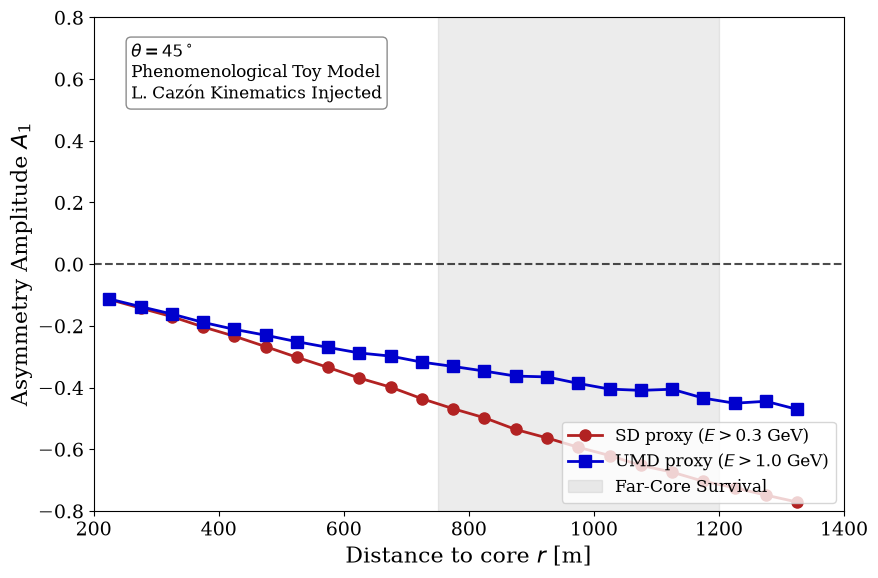

In [15]:
# =============================================================================
# 4. EXTRACCIÓN DE A1 Y GRAFICACIÓN (Estilo Publicación)
# =============================================================================
# Bines radiales para explorar desde el core hasta el far-core
r_bins = np.arange(200, 1400, 50)
phi_bins = np.linspace(-180, 180, 25) # 12 bines de 30 grados
phi_centers = 0.5 * (phi_bins[1:] + phi_bins[:-1])

A1_SD, A1_UMD, r_centers = [], [], []

for i in range(len(r_bins)-1):
    r_min, r_max = r_bins[i], r_bins[i+1]
    r_centers.append((r_min + r_max) / 2.0)
    
    for det_name, df_det, A1_list in zip(['SD', 'UMD'], [df_SD, df_UMD], [A1_SD, A1_UMD]):
        mask = (df_det['r'] >= r_min) & (df_det['r'] < r_max)
        df_bin = df_det[mask]
        
        # Pesamos por los efectos fenomenológicos (Cazón + Decaimiento)
        counts, _ = np.histogram(df_bin['phi'], bins=phi_bins, weights=df_bin['weight'])
        raw_counts, _ = np.histogram(df_bin['phi'], bins=phi_bins) # Para Poisson
        
        valid_bins = raw_counts > 15
        
        if np.sum(valid_bins) > 6:
            phi_fit = phi_centers[valid_bins]
            counts_fit = counts[valid_bins]
            raw_fit = raw_counts[valid_bins]
            
            mean_density = np.mean(counts_fit)
            y_norm = counts_fit / mean_density
            y_err_norm = (np.sqrt(raw_fit) / raw_fit) * y_norm # Error de Poisson propagado
            
            try:
                popt, _ = curve_fit(
                    harmonic_model, phi_fit, y_norm, 
                    sigma=y_err_norm, absolute_sigma=True, bounds=(-2.0, 2.0)
                )
                A1_list.append(popt[0])
            except RuntimeError:
                A1_list.append(np.nan)
        else:
            A1_list.append(np.nan)

# Estética rigurosa
plt.rcParams.update({
    'font.size': 14, 'axes.labelsize': 16, 'legend.fontsize': 12,
    'xtick.labelsize': 14, 'ytick.labelsize': 14, 'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(r_centers, A1_SD, marker='o', linestyle='-', color='firebrick', 
        linewidth=2, markersize=8, label=r'SD proxy ($E > 0.3$ GeV)')
ax.plot(r_centers, A1_UMD, marker='s', linestyle='-', color='mediumblue', 
        linewidth=2, markersize=8, label=r'UMD proxy ($E > 1.0$ GeV)')

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvspan(750, 1200, color='gray', alpha=0.15, label='Far-Core Survival')

ax.set_xlabel(r'Distance to core $r$ [m]')
ax.set_ylabel(r'Asymmetry Amplitude $A_1$')
ax.set_ylim(-0.8, 0.8)
ax.set_xlim(200, 1400)

textstr = '\n'.join((
    r'$\theta = 45^\circ$',
    r'Phenomenological Toy Model',
    r'L. Cazón Kinematics Injected'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig.jpg')
plt.show()